# Load data

FAIRNESS TEST SUMMARY
Test Result: ✅ PASSED

Test Configuration:
  Regular Requesters: 10
  Malicious Requesters: 500
  Regular Request Rate: 50.0/s
  Malicious Request Rate: 5000.0/s
  Test Duration: 10s

Results:
  Baseline Latency: 7.0ms
  Regular Tenant Final Latency: 256.0ms
  Latency Increase: 3175.8%
  Regular Tenant Error Rate: 1.98%
  Malicious Tenant Error Rate: 0.00%

Generating plots...


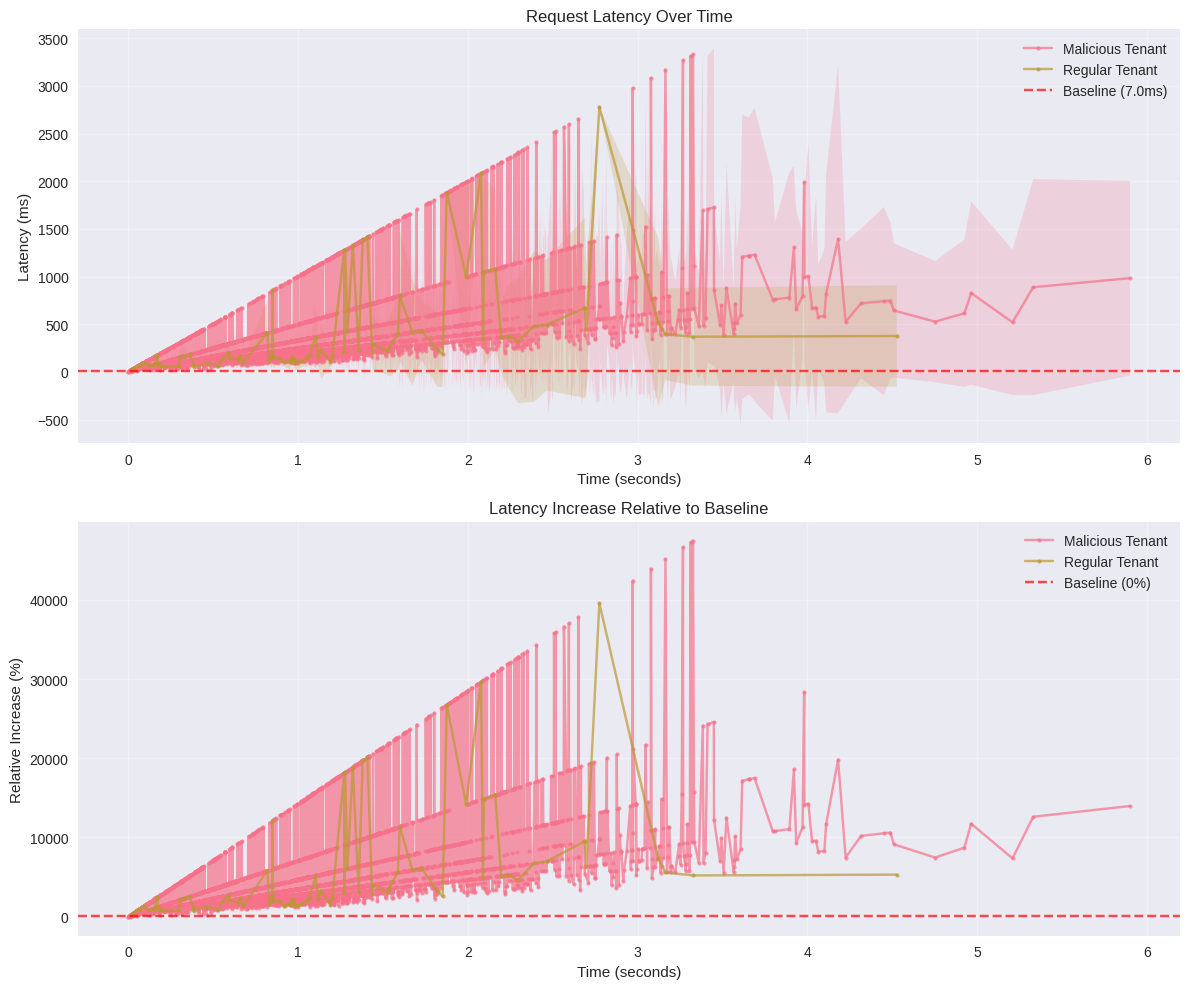

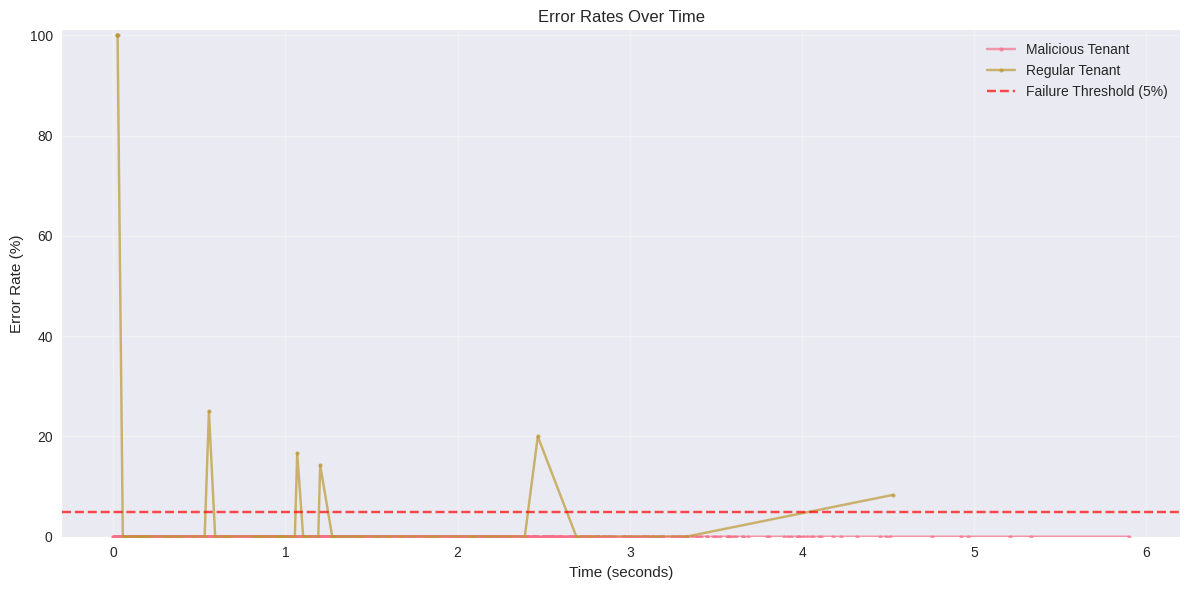

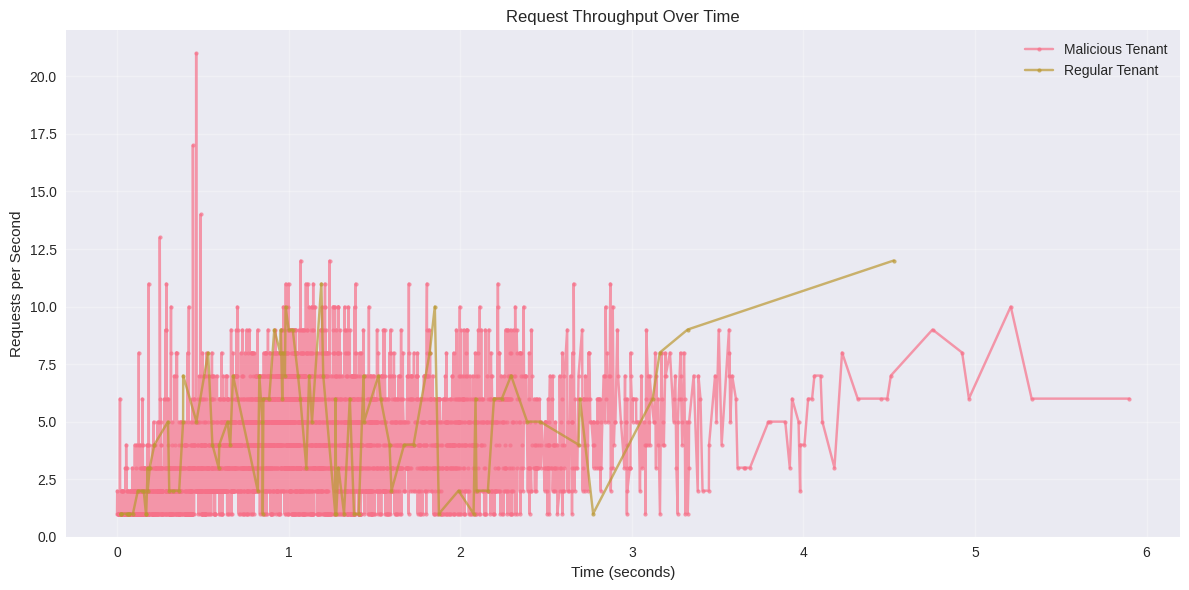

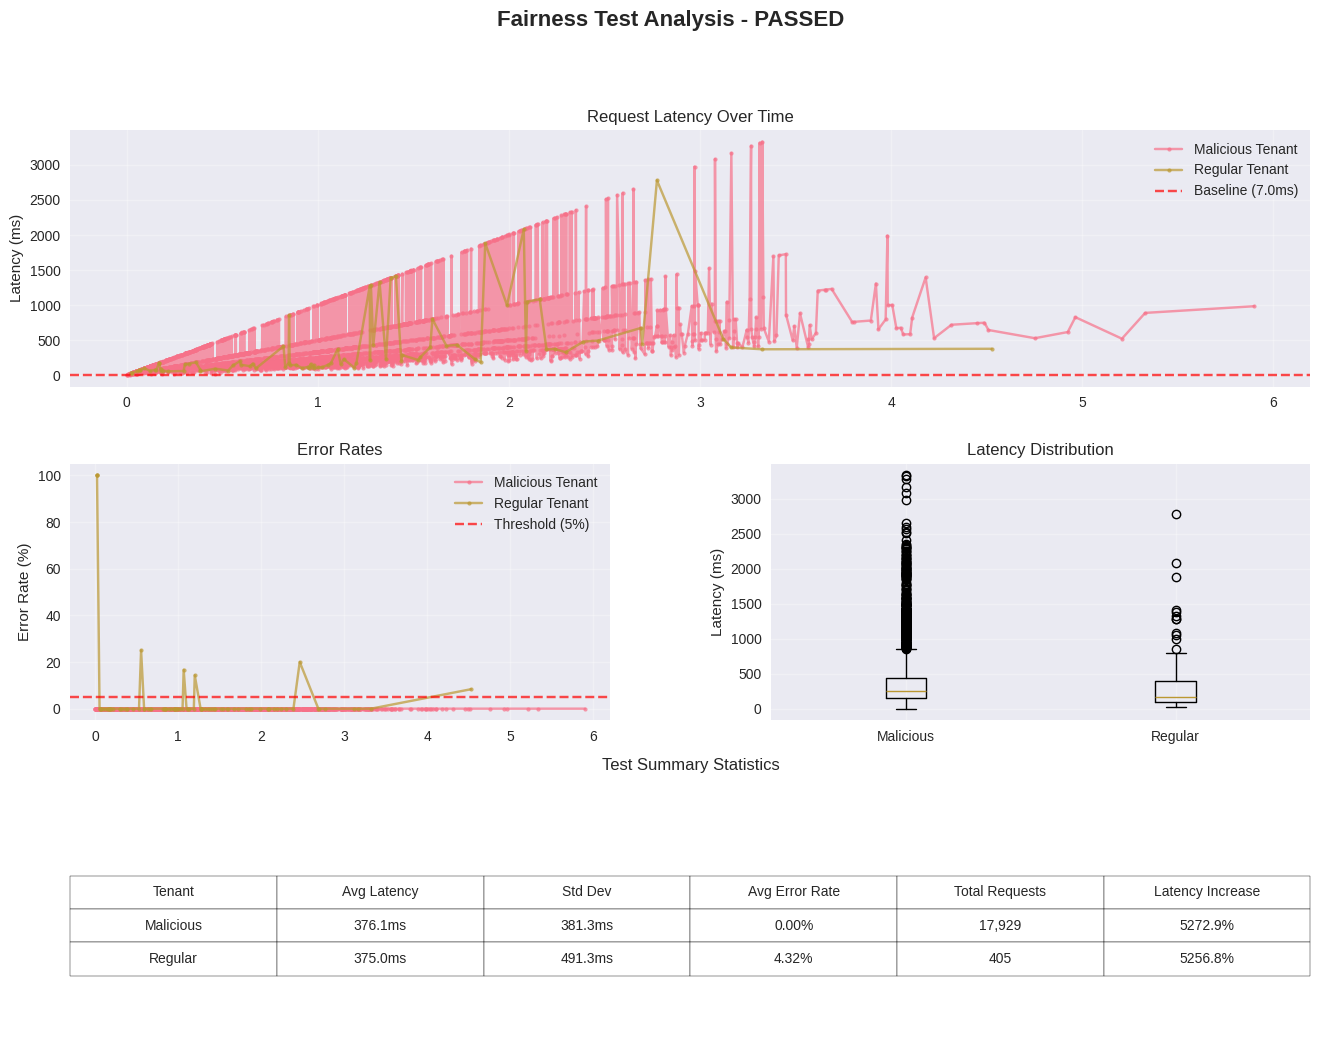


Analysis complete! Plots saved with timestamp: 1749331654


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_latest_test_data():
    """Load the most recent test data"""
    # Look for both regular and malicious data files
    regular_files = glob.glob("fairness_test_data_regular_*.csv")
    malicious_files = glob.glob("fairness_test_data_malicious_*.csv")
    
    if not regular_files and not malicious_files:
        raise FileNotFoundError("No test data files found")
    
    # Get the latest timestamp
    all_files = regular_files + malicious_files
    latest_file = max(all_files)
    timestamp = latest_file.split('_')[-1].split('.')[0]
    
    # Load both regular and malicious data
    dfs = []
    
    regular_file = f"fairness_test_data_regular_{timestamp}.csv"
    malicious_file = f"fairness_test_data_malicious_{timestamp}.csv"
    
    if glob.glob(regular_file):
        df_regular = pd.read_csv(regular_file)
        dfs.append(df_regular)
    
    if glob.glob(malicious_file):
        df_malicious = pd.read_csv(malicious_file)
        dfs.append(df_malicious)
    
    if not dfs:
        raise FileNotFoundError(f"No data files found for timestamp {timestamp}")
    
    # Combine the dataframes
    df = pd.concat(dfs, ignore_index=True)
    
    # Load metadata
    metadata_file = f"fairness_test_metadata_{timestamp}.json"
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    return df, metadata, timestamp

def preprocess_data(df, metadata):
    """Preprocess the data to add calculated columns"""
    # Convert start_time to numeric if it's not already
    df['start_time'] = pd.to_numeric(df['start_time'], errors='coerce')
    
    # Calculate elapsed seconds from the start of the test
    min_time = df['start_time'].min()
    df['elapsed_seconds'] = df['start_time'] - min_time
    
    # Calculate relative increase from baseline
    baseline_latency = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    df['relative_increase_percent'] = ((df['latency_ms'] - baseline_latency) / baseline_latency) * 100
    
    # Sort by time for proper plotting
    df = df.sort_values(['role', 'elapsed_seconds']).reset_index(drop=True)
    
    return df

def plot_latency_over_time(df, metadata, timestamp, save_plots=True):
    """Plot absolute latency over time"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot 1: Absolute Latency
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
            
        ax1.plot(role_data['elapsed_seconds'], role_data['latency_ms'], 
                label=f'{role} Tenant', marker='o', markersize=3, alpha=0.7)
        
        # Add error bars for standard deviation if the column exists
        if 'std_dev_ms' in role_data.columns:
            ax1.fill_between(role_data['elapsed_seconds'],
                            role_data['latency_ms'] - role_data['std_dev_ms'],
                            role_data['latency_ms'] + role_data['std_dev_ms'],
                            alpha=0.2)
    
    # Add baseline line
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline, color='red', linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_title('Request Latency Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Relative Increase
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
            
        ax2.plot(role_data['elapsed_seconds'], role_data['relative_increase_percent'], 
                label=f'{role} Tenant', marker='o', markersize=3, alpha=0.7)
    
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Baseline (0%)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Relative Increase (%)')
    ax2.set_title('Latency Increase Relative to Baseline')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'latency_analysis_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_error_rates(df, metadata, timestamp, save_plots=True):
    """Plot error rates over time"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
            
        ax.plot(role_data['elapsed_seconds'], role_data['error_rate'] * 100, 
                label=f'{role} Tenant', marker='o', markersize=3, alpha=0.7)
    
    # Add threshold line (5% error rate)
    ax.axhline(y=5, color='red', linestyle='--', alpha=0.7, 
               label='Failure Threshold (5%)')
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Error Rate (%)')
    ax.set_title('Error Rates Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Set reasonable y-axis limits
    max_error_rate = df['error_rate'].max() * 100 if len(df) > 0 else 10
    ax.set_ylim(0, max(max_error_rate + 1, 10))
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'error_rates_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_request_throughput(df, metadata, timestamp, save_plots=True):
    """Plot request throughput over time with proper aggregation per role"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Get the metrics send interval from config
    interval = metadata['test_config']['metrics_send_interval']['secs']
    
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        
        # Sort by elapsed time
        role_data = role_data.sort_values('elapsed_seconds')
        
        # Create time bins for aggregation
        max_time = role_data['elapsed_seconds'].max()
        time_bins = np.arange(0, max_time + interval, interval)
        
        # Aggregate throughput by time bins
        throughput_data = []
        time_points = []
        
        for i in range(len(time_bins) - 1):
            bin_start = time_bins[i]
            bin_end = time_bins[i + 1]
            
            # Find all data points within this time bin
            bin_mask = (role_data['elapsed_seconds'] >= bin_start) & (role_data['elapsed_seconds'] < bin_end)
            bin_data = role_data[bin_mask]
            
            if len(bin_data) > 0:
                # Sum all requests within this time interval
                total_requests_in_bin = bin_data['total_requests'].sum()
                throughput = total_requests_in_bin / interval
                
                throughput_data.append(throughput)
                time_points.append((bin_start + bin_end) / 2)  # Use midpoint of interval
        
        if throughput_data:
            ax.plot(time_points, throughput_data, 
                    label=f'{role} Tenant', marker='o', markersize=4, alpha=0.8)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Requests per Second')
    ax.set_title('Request Throughput Over Time (Aggregated by Role)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_plots:
        plt.savefig(f'throughput_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_summary_dashboard(df, metadata, timestamp, save_plots=True):
    """Create a comprehensive dashboard"""
    fig = plt.figure(figsize=(16, 12))
    
    # Create a 3x2 grid
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Latency over time
    ax1 = fig.add_subplot(gs[0, :])
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        ax1.plot(role_data['elapsed_seconds'], role_data['latency_ms'], 
                label=f'{role} Tenant', marker='o', markersize=3, alpha=0.7)
    
    baseline = metadata['baseline_metrics']['tenant1_avg_latency_ms']
    ax1.axhline(y=baseline, color='red', linestyle='--', alpha=0.7, 
                label=f'Baseline ({baseline:.1f}ms)')
    ax1.set_title('Request Latency Over Time')
    ax1.set_ylabel('Latency (ms)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Error rates
    ax2 = fig.add_subplot(gs[1, 0])
    for role in df['role'].unique():
        role_data = df[df['role'] == role].copy()
        if len(role_data) == 0:
            continue
        ax2.plot(role_data['elapsed_seconds'], role_data['error_rate'] * 100, 
                label=f'{role} Tenant', marker='o', markersize=3, alpha=0.7)
    ax2.axhline(y=5, color='red', linestyle='--', alpha=0.7, label='Threshold (5%)')
    ax2.set_title('Error Rates')
    ax2.set_ylabel('Error Rate (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Box plot of latencies
    ax3 = fig.add_subplot(gs[1, 1])
    if len(df) > 0:
        latency_data = [df[df['role'] == role]['latency_ms'].values for role in df['role'].unique()]
        labels = df['role'].unique()
        ax3.boxplot(latency_data, labels=labels)
    ax3.set_title('Latency Distribution')
    ax3.set_ylabel('Latency (ms)')
    ax3.grid(True, alpha=0.3)
    
    # 4. Summary statistics table
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('tight')
    ax4.axis('off')
    
    # Create summary table
    summary_data = []
    for role in df['role'].unique():
        role_data = df[df['role'] == role]
        if len(role_data) == 0:
            continue
            
        avg_latency = role_data['latency_ms'].mean()
        std_latency = role_data['latency_ms'].std()
        avg_error_rate = role_data['error_rate'].mean()
        total_requests = role_data['total_requests'].sum()
        latency_increase = ((avg_latency - baseline) / baseline * 100) if baseline > 0 else 0
        
        summary_data.append([
            role,
            f"{avg_latency:.1f}ms",
            f"{std_latency:.1f}ms",
            f"{avg_error_rate * 100:.2f}%",
            f"{total_requests:,}",
            f"{latency_increase:.1f}%"
        ])
    
    if summary_data:
        table = ax4.table(cellText=summary_data,
                          colLabels=['Tenant', 'Avg Latency', 'Std Dev', 'Avg Error Rate', 
                                   'Total Requests', 'Latency Increase'],
                          cellLoc='center',
                          loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
    ax4.set_title('Test Summary Statistics', pad=20)
    
    # Add test result
    test_result = "PASSED" if metadata.get('test_passed', False) else "FAILED"
    fig.suptitle(f'Fairness Test Analysis - {test_result}', fontsize=16, fontweight='bold')
    
    if save_plots:
        plt.savefig(f'fairness_dashboard_{timestamp}.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_test_summary(metadata):
    """Print a detailed test summary"""
    print("=" * 60)
    print("FAIRNESS TEST SUMMARY")
    print("=" * 60)
    
    config = metadata.get('test_config', {})
    baseline = metadata.get('baseline_metrics', {})
    final = metadata.get('final_results', {})
    
    print(f"Test Result: {'✅ PASSED' if metadata.get('test_passed', False) else '❌ FAILED'}")
    print()
    
    print("Test Configuration:")
    print(f"  Regular Requesters: {config.get('regular_requesters', 'N/A')}")
    print(f"  Malicious Requesters: {config.get('malicious_requesters', 'N/A')}")
    print(f"  Regular Request Rate: {config.get('regular_request_rate', 'N/A')}/s")
    print(f"  Malicious Request Rate: {config.get('malicious_request_rate', 'N/A')}/s")
    print(f"  Test Duration: {config.get('test_duration', {}).get('secs', 'N/A')}s")
    print()
    
    print("Results:")
    print(f"  Baseline Latency: {baseline.get('tenant1_avg_latency_ms', 'N/A'):.1f}ms")
    print(f"  Regular Tenant Final Latency: {final.get('regular_avg_latency_ms', 'N/A'):.1f}ms")
    print(f"  Latency Increase: {final.get('regular_relative_increase_percent', 'N/A'):.1f}%")
    print(f"  Regular Tenant Error Rate: {final.get('regular_error_rate', 0) * 100:.2f}%")
    print(f"  Malicious Tenant Error Rate: {final.get('malicious_error_rate', 0) * 100:.2f}%")

# Main analysis function
def analyze_fairness_test():
    """Run complete analysis"""
    try:
        df, metadata, timestamp = load_latest_test_data()
        
        # Preprocess the data
        df = preprocess_data(df, metadata)
        
        print_test_summary(metadata)
        print("\nGenerating plots...")
        
        plot_latency_over_time(df, metadata, timestamp)
        plot_error_rates(df, metadata, timestamp)
        plot_request_throughput(df, metadata, timestamp)
        plot_summary_dashboard(df, metadata, timestamp)
        
        print(f"\nAnalysis complete! Plots saved with timestamp: {timestamp}")
        
        return df, metadata
        
    except Exception as e:
        print(f"Error during analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Run the analysis
df, metadata = analyze_fairness_test()